# Validation Pipeline Sketch V5
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [444]:
import multiprocessing
import random
import warnings

from dataclasses import dataclass, field
from joblib import Parallel, delayed
from pathlib import Path
from typing import (
    Any, Callable, Dict, List, Optional, Tuple, Type, Union 
)

from tqdm.notebook import tqdm

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

from scipy import sparse
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import squareform

from sklearn.base import ClusterMixin, TransformerMixin
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, confusion_matrix, pairwise_distances, silhouette_score
from sklearn.metrics.cluster import contingency_matrix
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, StandardScaler
from sklearn.utils import check_random_state

import umap

import matplotlib.pyplot as plt

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
def plot_dim_reduced_clustering(
    X: np.ndarray, 
    clusters: np.ndarray, 
    method: str = 'PCA', 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1,
    ax: plt.Axes = None, 
    show: bool = True
) -> plt.Axes:
    """
    Plot a 2D embedding of the data colored by cluster assignments.

    :param X: the input data matrix to be reduced and plotted (n_samples, n_features)
    :param clusters: cluster labels for each sample (n_samples,)
    :param method: dimensionality reduction method to use; either 'PCA' or 'tSNE'
    :param ax: a matplotlib axes object to be plotted on
    :param show: controls whether to call plt.show()

    :return: plt.Axes if show = False, otherwise displays a scatter plot with the samples colored by cluster assignment
    """
    # dimensionality reduction
    if method == 'PCA':
        X_red = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
    elif method == 'tSNE':
        X_red = TSNE(
            n_components=2,
            random_state=RANDOM_SEED,
            perplexity=perplexity
        ).fit_transform(X)
    elif method == 'UMAP':
        X_red = umap.UMAP(
            n_components=2, 
            n_neighbors=n_neighbors, 
            min_dist=min_dist, 
            random_state=RANDOM_SEED  # throws a warning
        ).fit_transform(X)
    else:
        raise ValueError(f"Unknown dimensionality reduction method {method}. Use one of 'PCA', 'tSNE', or 'UMAP'.")

    # build discrete colormap for clusters
    unique_clusters = np.unique(clusters)
    base_cmap = plt.get_cmap('Set1', len(unique_clusters))
    color_dict = {lab: base_cmap(i) for i, lab in enumerate(unique_clusters)}

    # plot points
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    point_colors = [color_dict[lab] for lab in clusters]
    ax.scatter(X_red[:, 0], X_red[:, 1], c=point_colors, s=10, alpha=0.8)

    # handle legend
    for lab in unique_clusters:
        ax.scatter([], [], c=[color_dict[lab]], label=f"cluster {lab}", s=50, alpha=0.8)
        
    ax.legend(loc='lower right', frameon=False)

    # titles & axis labels
    if method == 'PCA':
        ax.set(
            title="PCA of Data Set",
            xlabel="PCA 1",
            ylabel="PCA 2"
        )
    elif method == 'tSNE':
        ax.set(
            title="t-SNE of Data Set",
            xlabel="t-SNE 1",
            ylabel="t-SNE 2"
        )
    else:
        ax.set(
            title="UMAP of Data Set",
            xlabel="UMAP 1",
            ylabel="UMAP 2"
        )

    if show:
        plt.tight_layout()
        plt.show()
    else:
        return ax

def map_clusterings(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_idx, col_idx = linear_sum_assignment(-cm)
    return dict(zip(col_idx, row_idx))

### 0.2 Data Import:

PANCAN dataset:

In [48]:
data_dir = Path('./data/TCGA-PANCAN-HiSeq-801x20531')
data_fp = data_dir / 'data.csv'
labels_fp = data_dir / 'labels.csv'

labels = pd.read_csv(labels_fp, header=None, skiprows=1)

sample = pd.read_csv(data_fp, header=None, skiprows=1, nrows=100, low_memory=False)
numeric_cols = [
    col
    for col in sample.columns
    if pd.to_numeric(sample[col], errors='coerce').notna().all()
]

print(f"found {len(numeric_cols)} numeric cols out of {len(sample.columns)}")

data = pd.read_csv(
    data_fp,
    header=None,
    usecols=numeric_cols,
    skiprows=1, 
    dtype=float,
    low_memory=False
)

le = LabelEncoder()
y = le.fit_transform(labels[1])

X = data.values

print("X shape:", X.shape, " |  y shape:", y.shape)

found 20531 numeric cols out of 20532
X shape: (801, 20531)  |  y shape: (801,)


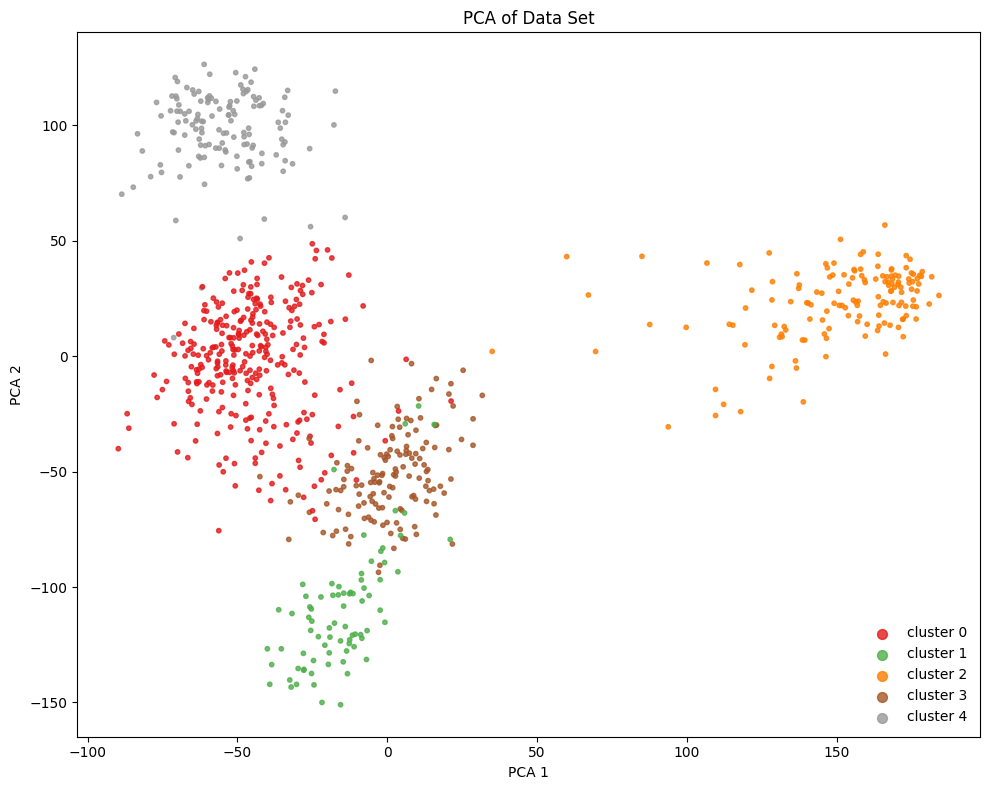

In [26]:
plot_dim_reduced_clustering(X, y, method='PCA')

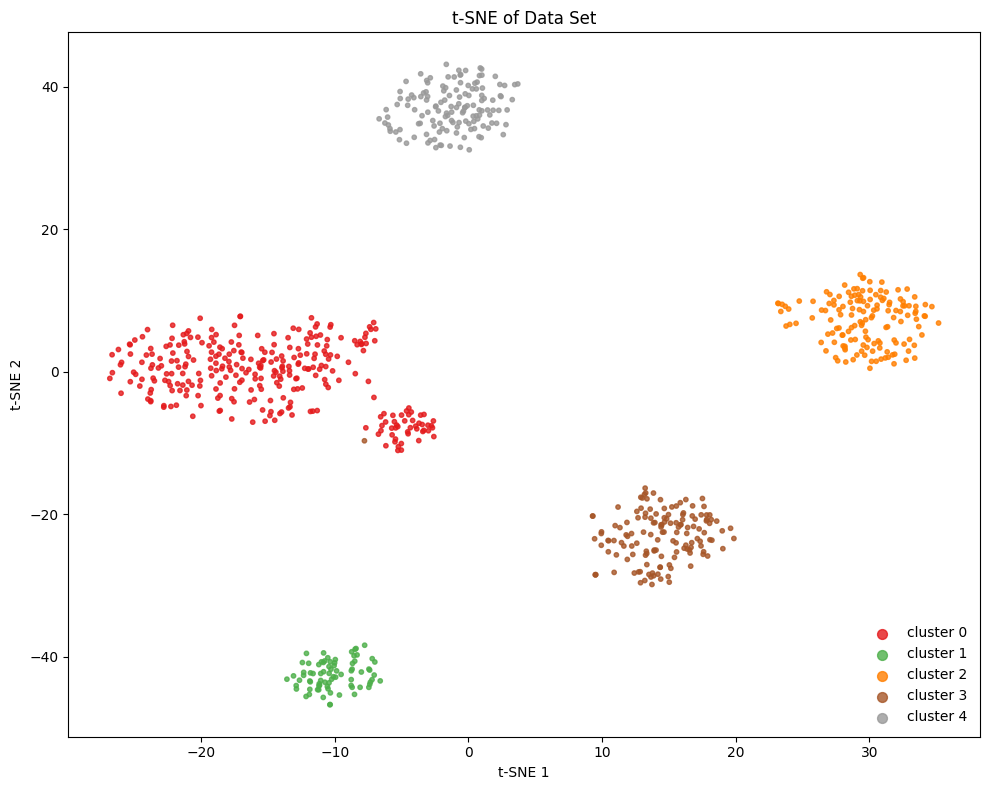

In [27]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


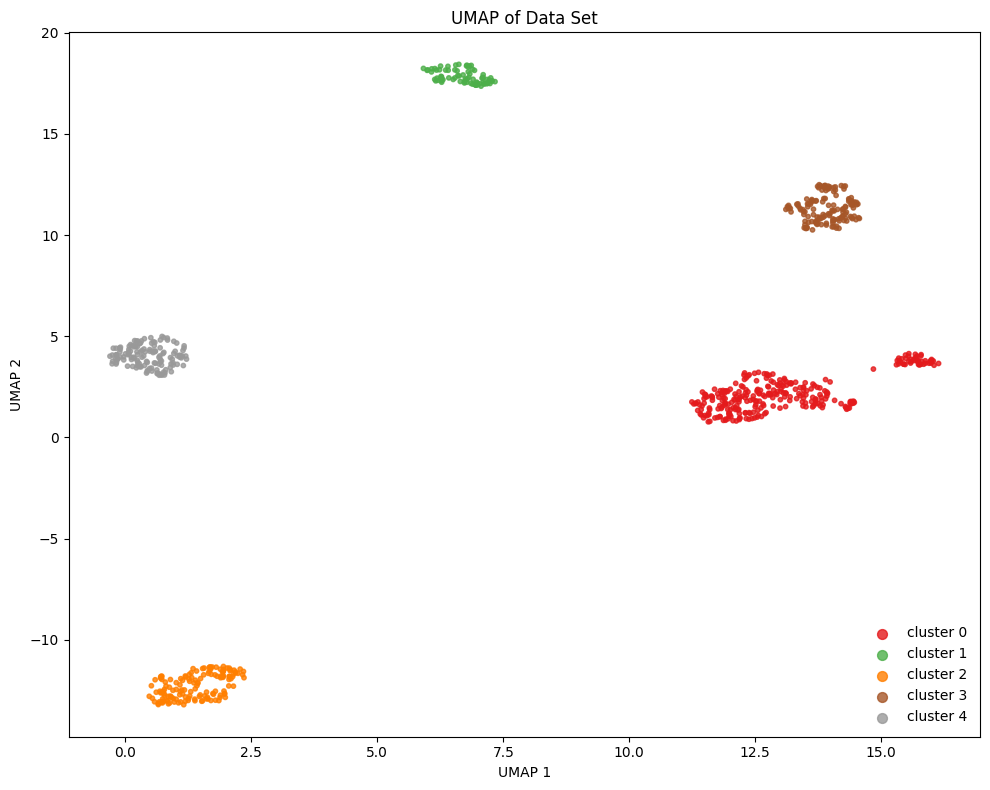

In [28]:
plot_dim_reduced_clustering(X, y, method='UMAP')

IRIS dataset:

In [49]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# print("X shape:", X_iris.shape, " |  y shape:", y_irisy.shape)

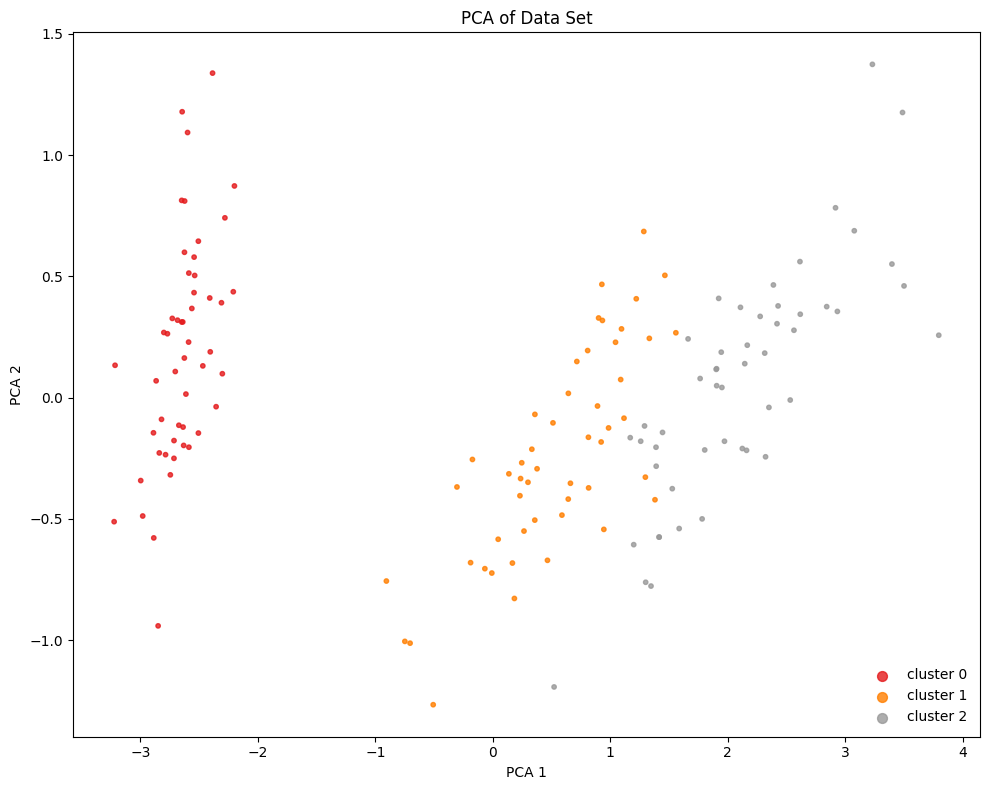

In [30]:
plot_dim_reduced_clustering(X, y, method='PCA')

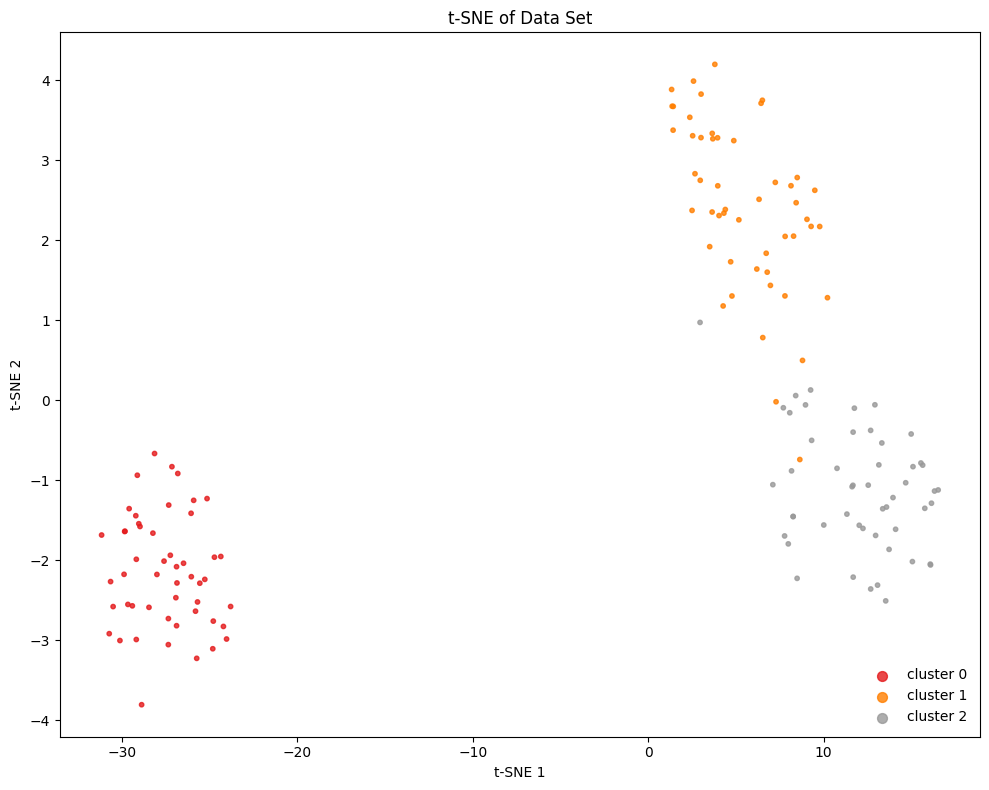

In [31]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


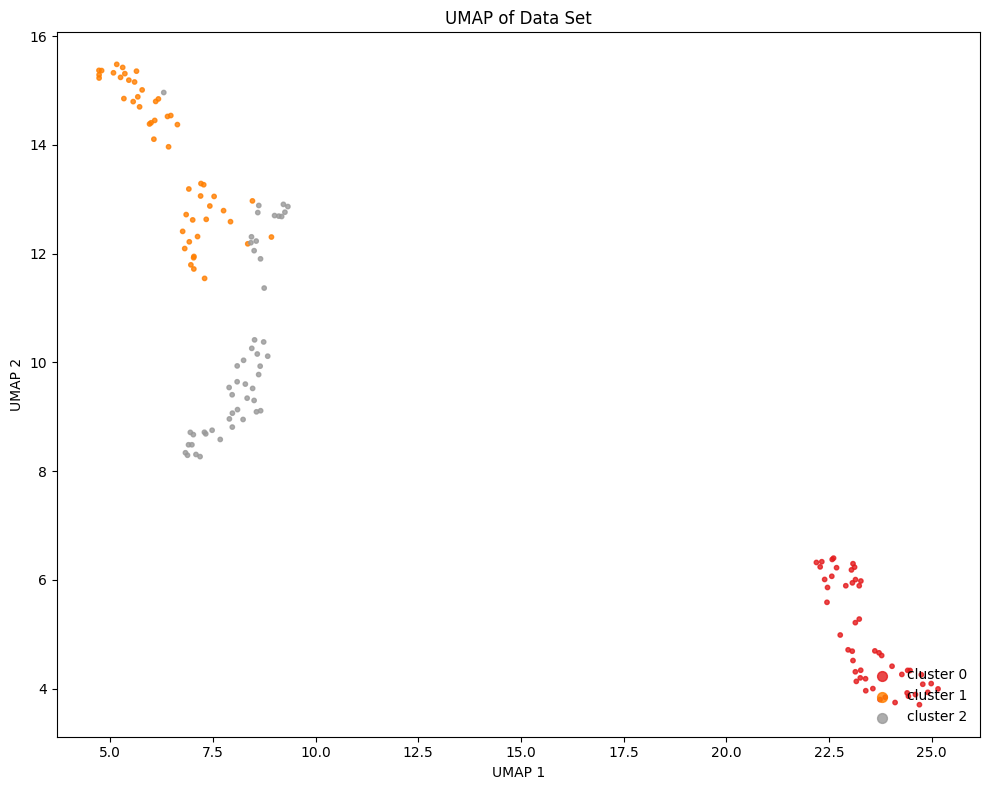

In [32]:
plot_dim_reduced_clustering(X, y, method='UMAP')

DARMANIS:

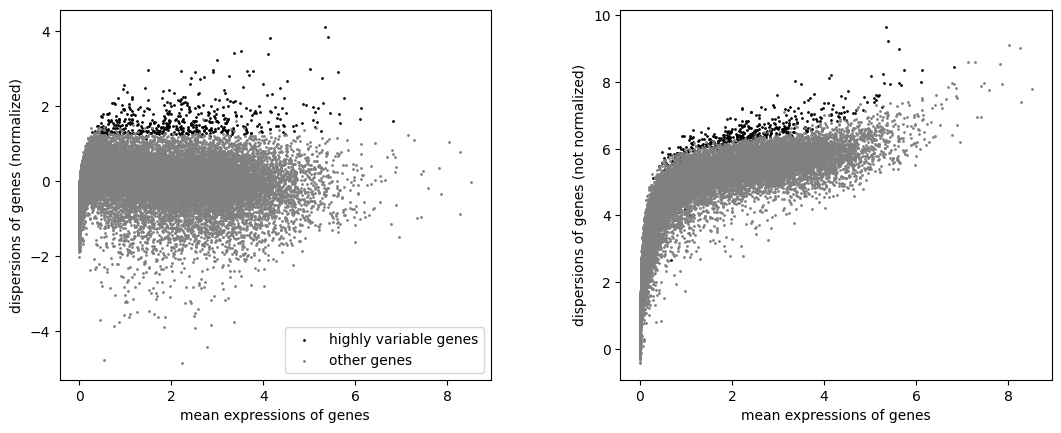

X shape: (3589, 500)


In [4]:
adata = ad.read_h5ad('data/DARMANIS/darmanis_fromraw.h5ad')

sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="Sample.name", flavor='seurat')
sc.pl.highly_variable_genes(adata)

adata_hvg = adata[:, adata.var['highly_variable']]
X = adata_hvg.X

print("X shape:", X.shape)

In [ ]:
plot_dim_reduced_clustering(X, y, method='PCA')

In [ ]:
plot_dim_reduced_clustering(X, y, method='tSNE')

In [ ]:
plot_dim_reduced_clustering(X, y, method='UMAP')

---

## 1. Data Simulation:

In [381]:
def simulate_clusters(
    n_total: int,
    p: int,
    k: int,
    cluster_scale: Union[float, List[float], Callable[[], float]] = 1.0,
    balanced: bool = True,
    cluster_sizes_frac: Optional[List[float]] = None,
    corr_type: str = "none",
    corr_strength: float = 1.0,
    block_size: Optional[int] = None,
    outliers: Union[int, float] = 0,
    outlier_scale: float = 5.0,
    outlier_mode: str = "far_gaussian",
    distribution: str = "gaussian",
    t_df: int = 3,
    nonlinear: bool = False,
    embed_dim: Optional[int] = None,
    embed_method: str = "random_fourier",
    embed_param: float = 2.0,
    center_box: float = 10.0,
    plotting: bool = True,
    random_state: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    simulate_clusters generates a synthetic dataset X (n_total × p) and 
    corresponding labels y (0..k-1 for clusters, -1 for outliers).

    :param n_total: total number of samples (including outliers)
    :param p: number of features
    :param k: number of clusters
    :param cluster_scale: overall spread parameter: 
        - single float → all clusters use σ² = cluster_scale 
        - list of length k → per-cluster σ² 
        - callable → draw σ² for each cluster via cluster_scale()
    :param balanced: if True, clusters are equal‐sized; else random (or via cluster_sizes)
    :param cluster_sizes_frac: array of cluster balances between 0 and 1, must sum to 1.
    :param corr_type: structure of within‐cluster covariance, one of: {"none", "ar1", "block"}
    :param corr_strength: ρ parameter for correlation (only used if corr_type ≠ "none")
    :param block_size: size of correlated blocks, only used if corr_type = "block"
    :param outliers: if int → number of outliers; if float in (0,1) → fraction of n_total
    :param outlier_scale: distance multiplier for placing outliers from global centroid
    :param outlier_mode: sampling strategy for outliers
    :param distribution: base distribution for cluster sampling
    :param t_df:
    :param nonlinear:
    :param embed_dim:
    :param enbed_method:
    :param center_box: bound for hyper-cube from which centroids are centered
    :param random_state: seed for reproducibility

    :return (X, y): tuple of np.ndarray, shape (n_total, p) and np.ndarray, shape (n_total, )
    """
    rng = np.random.default_rng(seed=random_state)
    
    # determine number of outliers
    if isinstance(outliers, float) and 0 < outliers < 1:
        n_outliers = np.floor(n_total * outliers)
    elif isinstance(outliers, int):
        n_outliers = outliers
    else:
        n_outliers = 0
        warnings.warn("`outliers` must be a non-negative int or a float in (0, 1). Defaulting to n_outliers = 0.")
    
    # consider total number of points to be clustered 
    n_total_clusters = n_total - n_outliers
    if n_total_clusters < 1:
        raise ValueError("`outliers` too large, no points left for clusters.")
    
    # handle cluster balancing
    if cluster_sizes_frac is not None:
        if len(cluster_sizes_frac) != k:
            raise ValueError(f"cluster_sizes_frac must have length k={k}.")
        total = float(np.sum(cluster_sizes_frac))
        if abs(total - 1.0) > 1e-8:
            warnings.warn('`cluster_sizes_frac` does not add up to 1. Rescaling cluster_sizes_frac.')
            total = np.sum(cluster_sizes_frac)
            cluster_sizes_frac = [frac / total for frac in cluster_sizes_frac]
        cluster_sizes = [int(np.floor(n_total_clusters * frac)) for frac in cluster_sizes_frac]
        for i in range(n_total_clusters - np.sum(cluster_sizes)):
            cluster_sizes[i % k] += 1
    elif balanced: 
        base_cluster_size = n_total_clusters // k
        cluster_sizes = [base_cluster_size] * k
        for i in range(n_total_clusters - (base_cluster_size * k)):
            cluster_sizes[i] += 1
    else:
        probs = rng.dirichlet(alpha=np.ones(k))
        cluster_sizes = list(np.floor(probs * n_total_clusters).astype(int))
        for i in range(n_total_clusters - np.sum(cluster_sizes)):
            cluster_sizes[i % k] += 1
    
    assert np.sum(cluster_sizes) == n_total_clusters
    
    # sample cluster centers
    if center_box < 0:
        center_box = -center_box
        warnings.warn('`center_box` should be a positive float. Negative value was passed, inverting passed value.')
    if center_box == 0.0:
        center_box = 10.0
        warnings.warn('`center_box` should be a positive float. Was 0 passed instead? Defaulting to 10.0.')
    centers = rng.uniform(
        low=-center_box, 
        high=center_box, 
        size=(k, p)
    )
    
    # get per‐cluster scale values
    if callable(cluster_scale):
        cluster_scales = [cluster_scale() for _ in range(k)]
    elif isinstance(cluster_scale, list):
        if len(cluster_scale) != k: 
            raise ValueError('Passed `cluster_scale` parameter must be of size k.')
        cluster_scales = cluster_scale
    else:
        cluster_scales = [cluster_scale] * k
        
    # handle correlation
    if corr_type == 'none':
        R = np.eye(p)
    elif corr_type == 'ar1':
        R = np.fromfunction(
            lambda i, j: corr_strength ** np.abs(i-j), 
            (p, p),
            dtype=float
        )
    elif corr_type:
        if block_size is None:
            raise ValueError("`block_size` must be provided when corr_type='block'")
        R = np.zeros((p, p))
        for start in range(0, p, block_size):
            end = min(start + block_size, p)
            R[start:end, start:end] = corr_strength
        np.fill_diagonal(R, 1.0)
    else:
        raise ValueError(f"Unknown corr_type `{corr_type}`")

    covs = [scale * R for scale in cluster_scales]
    
    # sample X
    X_parts, y_parts = [], []
    
    for c in range(k):
        size = cluster_sizes[c]
        mean = centers[c]
        cov = covs[c]
        
        if distribution == "gaussian":
            X_c = rng.multivariate_normal(mean=mean, cov=cov, size=size)
        elif distribution == "t":
            # multivariate t:  X = μ + L z * sqrt(df / v), z~N(0,I), v~χ²(df)
            df = t_df
            L = np.linalg.cholesky(cov)
            z = rng.standard_normal((size, p))
            v = rng.chisquare(df, size=(size, 1))
            X_c = mean + (z @ L.T) * np.sqrt(df / v)
        elif distribution == 'uniform_ball':
            # sample uniform in p-ball of radius = √(trace(Σ)/p)
            r_max = np.sqrt(np.trace(cov) / p)
            U = rng.standard_normal((size, p))
            U /= np.linalg.norm(U, axis=1, keepdims=True)
            radii = rng.random(size) ** (1/p) * r_max
            X_c = mean + U * radii.reshape(-1, 1)
        else:
            raise ValueError("`distribution` must be one of: {\"gaussian\", \"t\", or \"uniform_ball\"}.")
        
        X_parts.append(X_c)
        y_parts.append(np.full(cluster_sizes[c], c, dtype=int))
        
    # sample outliers
    if n_outliers > 0:
        global_centroid = np.average(centers, axis=0, weights=cluster_sizes)
        
        avg_cov = np.sum(cluster_sizes[c] * covs[c] for c in range(k)) / np.sum(cluster_sizes)
        global_sigma = np.sqrt(np.mean(np.diag(avg_cov)))
        
        if outlier_mode == 'far_gaussian':
            U = rng.standard_normal(size=(n_outliers, p))
            U /= np.linalg.norm(U, axis=1, keepdims=True)
            X_out = global_centroid + outlier_scale * global_sigma * U
        elif outlier_mode == 'uniform_box':
            box = center_box * outlier_scale
            X_out = rng.uniform(-box, +box, size=(n_outliers, p))
        else:
            raise ValueError(f"unknown outlier_mode `{outlier_mode}`")

        X_parts.append(X_out)
        y_parts.append(np.full(n_outliers, -1, dtype=int))
        
    # concatenate and shuffle        
    X = np.vstack(X_parts)  # shape (n_total, p)
    y = np.concatenate(y_parts)  # shape (n_total,)

    perm = rng.permutation(len(y))
    X = X[perm]
    y = y[perm]
    
    if nonlinear:
        if embed_method == 'fourier':
            freq_scale = 0.1  
            W = rng.normal(scale=freq_scale, size=(p, embed_dim))
            b = rng.uniform(0, 2*np.pi, size=(embed_dim,))
            X = np.sin(X @ W + b)
        elif embed_method == 'poly':
            d = embed_param
            
            X = np.hstack([
                X,
                X**d,
                (X[:, [0]] * X[:, [1]]),
            ])
        elif embed_method == 'rbf':
            sigma_rbf = embed_param
            
            prototypes = X[rng.choice(len(X), size=50, replace=False)]
            gamma = 1.0 / (2 * sigma_rbf**2)
            X = np.exp(-gamma * ((X[:,None,:] - prototypes[None,:,:])**2).sum(-1))
    
    # visualize
    if plotting:
        pca = PCA(n_components=2, random_state=random_state)
        X_pca = pca.fit_transform(X)

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(
            X_pca[:, 0], X_pca[:, 1],
            c=y, cmap='tab10', edgecolors='k', alpha=0.8
        )
        plt.title("PCA projection of simulated clusters")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    return X, y

---

## 2. Cluster Analysis with Resampling for Validation and Exploration (CARVE) Algorithm:

In [6]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


carve/utils.py:

In [7]:
def subsample_indices(n_samples: int, ratio: float = 0.6, seed: int = None) -> tuple[np.ndarray, np.ndarray]:
    """
    draw a subsample of indices of size floor(ratio * n_samples).
    
    :param n_samples: total number of samples in data frame.
    :param ratio: ratio for subsampling, between 0 and 1. 
    :param seed: random seed for rng.
    
    :return:
        train_idx: 1D array of length floor(ratio * n_samples).
        test_idx: the complement indices (length = n_samples - len(train_idx)).
    """
    rng = np.random.RandomState(seed)
    all_idx = np.arange(n_samples)
    train_size = int(np.float64(ratio * n_samples))
    
    train_idx = rng.choice(all_idx, size=train_size, replace=False)
    test_idx = np.setdiff1d(all_idx, train_idx)
    
    return train_idx, test_idx

def clustering_pipeline(
    X: np.ndarray,
    est_cls: Type[ClusterMixin],
    **params: Any
) -> np.ndarray:
    """
    Fit estimator on X and return labels.

    :param X: Data array, shape (n_samples, n_features).
    :param est_cls: Clustering estimator class.
    :param params: Hyperparameters for estimator.
    
    :return: Array of labels, shape (n_samples,).
    """
    estimator = est_cls(**params)

    if hasattr(estimator, "fit_predict"):
        return estimator.fit_predict(X)
    estimator.fit(X)
    return getattr(estimator, "labels_")

def wrangle_pipeline_df(pipeline_records):
    rows = []
    for record in pipeline_records:
        params = record['params']
        k = params['n_clusters']
        
        for r in record['results']:
            ari_s, ari_g, *_, norm_p, dr_p, norm_name, dr_name = r
            
            if norm_name != 'FunctionTransformer':
                norm_label = norm_name
            else:
                func = norm_p.get('func', None)
                norm_label = func.__name__ if func is not None else 'identity'
            
            if dr_name != 'FunctionTransformer':
                dr_label = dr_name
            else:
                func = dr_p.get('func', None)
                dr_label = func.__name__ if func is not None else 'identity'
                
            rows.append({
                'n_clusters': k, 
                'norm__func': norm_label,
                'dr__method': dr_label, 
                'ari_stability': ari_s, 
                'ari_generalizability': ari_g 
            })
        
    dfp = pd.DataFrame(rows)
    
    return (
        dfp
        .groupby(['norm__func', 'dr__method', 'n_clusters'], as_index=False)
        .mean()
    )
    
def align_labels(
    true_labels: np.ndarray, 
    pred_labels: np.ndarray
) -> np.ndarray:
    """
    relabel pred_labels to best match true_labels via hungarian algorithm.
    returns an array of the same shape as pred_labels.
    """
    # get contingency matrix
    cont = contingency_matrix(true_labels, pred_labels)
    
    # solve assignment on -cont to max matches
    row_ind, col_ind = linear_sum_assignment(-cont)
    
    # align order
    true_classes = np.unique(true_labels)
    pred_classes = np.unique(pred_labels)
    
    # build mapping
    mapping = {
        pred_classes[col]: true_classes[row]
        for row, col in zip(row_ind, col_ind)
    }
    
    for pc in pred_classes:
        mapping.setdefault(pc, pc)

    # apply mapping
    aligned = np.array([mapping[lbl] for lbl in pred_labels], dtype=true_labels.dtype)
    return aligned

carve/preprocessing.py

In [8]:
PipelineSpec = Tuple[Pipeline, Dict[str, Any], Dict[str, Any]]

def default_norm_options() -> List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]]:
    """
    Generate default normalization options.
    
    :return: norm_options
    """
    norm_options = [
        (FunctionTransformer, {}),
        (StandardScaler, {}),
        (FunctionTransformer, {'func': [np.log1p]}),
    ]

    return norm_options

def default_dr_options(
    X: np.ndarray, 
    rho: float = 0.6
) -> List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]]:
    """
    Generate default dimensionality-reduction options.

    :param X: Input data array.
    :param rho: Subsampling ratio to determine max DR dims.
    
    :return: dr_options
    """
    n_samples, p = X.shape
    min_n = int(round(n_samples * (1 - rho))) - 1

    dr_options = [
        (FunctionTransformer, {}),
        (PCA, {'n_components': list(range(2, min(min_n, p) + 1))}),
        (TSNE, {'n_components': [2, 3], 'perplexity': list(range(5, min(min_n, 51)))}),
        (umap.UMAP, {'n_components': list(range(2, min(min_n, p) + 1)), 
                     'n_neighbors': list(range(5, 51)), 'min_dist': [0.1]}),
    ]

    return dr_options

def draw_random_pipeline(
    norm_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    dr_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    seed: int = 0
) -> PipelineSpec:
    """
    randomly choose one normalization+DR combo and random hyperparameters.
    """
    rnd = random.Random(seed)
        
    norm_cls, norm_grid = rnd.choice(norm_options)
    dr_cls, dr_grid = rnd.choice(dr_options)
    
    norm_params = {k: rnd.choice(v) for k, v in norm_grid.items()}
    dr_params = {k: rnd.choice(v) for k, v in dr_grid.items()}
    
    norm = norm_cls(**norm_params)
    dr = dr_cls(**dr_params)
    
    pipeline = Pipeline([('norm', norm), ('dr', dr)])
    return pipeline, norm_params, dr_params

carve/metrics.py

In [45]:
IndexLabels = Tuple[np.ndarray, np.ndarray]  # (indices, labels)
PredLabels = Tuple[np.ndarray, np.ndarray, np.ndarray]  # (idx, true, pred)

def build_consensus_matrix(
    n: int,
    runs: List[IndexLabels]
) -> np.ndarray:
    """
    runs: list of (idx, labels) from B bootstraps
    """
    M_sum = np.zeros((n, n), dtype=float)
    I_sum = np.zeros((n, n), dtype=float)
    
    for idx, labels in runs:
        I_sum[np.ix_(idx, idx)] += 1  # mark which pairs were ever co-sampled
        
        # increment same-cluster counts
        for lab in np.unique(labels):
            pts = idx[labels == lab]
            M_sum[np.ix_(pts, pts)] += 1
        
    # build consensus fraction
    with np.errstate(divide='ignore', invalid='ignore'):
        M = M_sum / I_sum
    M[I_sum == 0] = 0  # set never-sampled pairs to 0
    
    # reorder by average-linkage dendrogram
    dists = squareform(1.0 - M, checks=False)
    Z = linkage(dists, method='average')
    order = leaves_list(Z)

    return M[np.ix_(order, order)]

def build_variance_array(
    n: int,
    runs: List[IndexLabels]
) -> np.ndarray:
    """
    returns, for each of the n points, the fraction of runs
    in which its label equals the most common label for that point.
    """
    B = len(runs)
    max_label = max(labels.max() for _, labels in runs)
    K = int(max_label) + 1
    onehot = np.zeros((B, n, K), dtype=int)
    for b, (idx, labels) in enumerate(runs):
        onehot[b, idx, labels] = 1

    probs = onehot.mean(axis=0)
    return np.sum(probs * (1 - probs), 1)

def build_centroid_variance_array(
    n: int,
    X: np.ndarray,
    runs: List[IndexLabels]
) -> np.ndarray:
    """
    runs: list of (idx, labels) from B bootstraps
    """
    B = len(runs)
    label_mat = np.full((B, n), np.nan, dtype=float)
    
    for b, (idx, labels) in enumerate(runs):
        X_b = X[idx]  # shape (n_bootstrap, n_features)
        centroids = {
            lab: X_b[labels == lab].mean(axis=0)
            for lab in np.unique(labels)
        }
        
        assigned = np.vstack([centroids[lab] for lab in labels])  # shape (n_bootstrap, n_features)
        errors = np.sqrt(np.mean((X_b - assigned)**2, axis=1))
        
        label_mat[b, idx] = errors
    
    var = np.nanvar(label_mat, axis=0)
    return var

def build_misclassification_array(
    n: int,
    runs: List[PredLabels]
) -> np.ndarray:
    """
    runs: list of (idx, true_labels, pred_labels)
    """
    correct = np.zeros(n, int)
    total = np.zeros(n, int)
    
    for idx, true, pred in runs:
        corr = (true == pred)
        np.add.at(correct, idx, corr.astype(int))
        np.add.at(total, idx, 1)
        
    mis = np.ones(n, float)
    valid = total > 0
    mis[valid] = 1.0 - (correct[valid] / total[valid])
    return mis

carve/plotting.py

In [46]:
def plot_results(
    validator,
    measure: str = 'overall'
) -> None:
    """
    plot ari vs. n_clusters for each clustering method + hyperparams,
    and include an overall average performance and indicators for optimal k and best method per k.

    :param method_df: dataframe with columns
        ['estimator', hyperparam cols..., 'n_clusters',
         'ari_stability', 'ari_generalizability', 'ari_overall']
    :param measure: one of 'stability', 'generalizability', or 'overall'
    """
    method_df = validator.method_df
    
    # select column, titles, ylabel
    if measure == 'stability':
        col = 'ari_stability'
        ylabel = 'stability (ARI)'
        title = 'stability per clustering configuration'
    elif measure == 'generalizability':
        col = 'ari_generalizability'
        ylabel = 'generalizability (ARI)'
        title = 'generalizability per clustering configuration'
    elif measure == 'overall':
        col = 'ari_overall'
        ylabel = 'overall (mean) ARI'
        title = 'overall ARI per clustering configuration'
    else:
        raise ValueError(f"invalid measure: {measure}")

    fig, ax = plt.subplots(figsize=(10, 8))

    # compute overall average across all methods
    avg_series = method_df.groupby('n_clusters')[col].mean()
    ax.plot(
        avg_series.index,
        avg_series.values,
        marker='D',
        linestyle='--',
        label='overall average'
    )

    # draw vertical line at optimal k
    optimal_k = int(avg_series.idxmax())
    ax.axvline(
        optimal_k,
        linestyle=':',
        linewidth=2,
        label=f'optimal overall at k={optimal_k}'
    )

    # determine best method at optimal_k
    subset_k = method_df[method_df['n_clusters'] == optimal_k]
    best_idx_k = subset_k[col].idxmax()
    best_row_k = method_df.loc[best_idx_k]
    # build best label string
    exclude = {'estimator', 'n_clusters', 'ari_stability', 'ari_generalizability', 'ari_overall'}
    param_cols = [c for c in best_row_k.index if c not in exclude]
    label_parts = []
    for pc in param_cols:
        val = best_row_k[pc]
        if pd.notna(val):
            label_parts.append(f"{pc}={val}")
    base_label = best_row_k['estimator'].lower()
    best_label = base_label + (f" ({', '.join(label_parts)})" if label_parts else '') + ' *'

    # plot each method
    for est in method_df['estimator'].unique():
        df_est = method_df[method_df['estimator'] == est]

        # identify hyperparam columns
        exclude = {'estimator', 'n_clusters', 'ari_stability', 'ari_generalizability', 'ari_overall'}
        param_cols = [c for c in df_est.columns if c not in exclude]

        # group by hyperparams
        if param_cols:
            groups = df_est.groupby(param_cols, dropna=False)
        else:
            groups = [(None, df_est)]

        for _, grp in groups:
            grp = grp.sort_values('n_clusters')

            # build label
            label_parts = []
            for pc in param_cols:
                val = grp.iloc[0][pc]
                if pd.notna(val):
                    label_parts.append(f"{pc}={val}")
            label = est.lower() + (f" ({', '.join(label_parts)})" if label_parts else '')
            is_best = (label + ' *' == best_label)
            plot_label = best_label if is_best else label

            ax.plot(
                grp['n_clusters'],
                grp[col],
                marker='o',
                label=plot_label
            )

            # circle best method at optimal_k
            if is_best:
                best_y = grp[grp['n_clusters'] == optimal_k][col].values[0]
                ax.scatter(
                    [optimal_k], [best_y],
                    facecolors='none',
                    edgecolors='black',
                    s=200,
                    linewidths=2
                )

    ax.set_xlabel('n_clusters')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    
def plot_consensus_matrix(
    validator,
    measure: str = 'overall', 
    k: int = None
) -> None:
    """
    Plot consensus matrix for the best clustering at a chosen k or automatically selected k.

    :param method_df: DataFrame with columns ['n_clusters', 'ari_stability', 'ari_generalizability', 'ari_overall', ...]
    :param cons_mats: list of consensus matrices corresponding to rows in method_df
    :param measure: one of 'stability', 'generalizability', or 'overall'
    :param k: optional number of clusters; if provided, use this k and skip overall averaging
    """
    method_df = validator.method_df
    cons_mats = validator.cons_mats
    
    # select metric column
    if measure == 'stability':
        col = 'ari_stability'
    elif measure == 'generalizability':
        col = 'ari_generalizability'
    elif measure == 'overall':
        col = 'ari_overall'
    else:
        raise ValueError(f"unknown measure {measure!r}")

    # determine optimal k if not provided
    if k is None:
        avg_per_k = method_df.groupby('n_clusters')[col].mean()
        optimal_k = int(avg_per_k.idxmax())
    else:
        optimal_k = k
        if optimal_k not in method_df['n_clusters'].unique():
            raise ValueError(f"provided k={optimal_k} not in method_df['n_clusters'] values")

    # pick best method
    subset_k = method_df[method_df['n_clusters'] == optimal_k]
    best_idx = subset_k[col].idxmax()
    best_row = method_df.loc[best_idx]

    # get consensus matrix
    C = cons_mats[best_idx]

    # build title
    fixed = {'estimator', 'n_clusters', 'ari_stability', 'ari_generalizability', 'ari_overall'}
    params = {
        key: best_row[key]
        for key in best_row.index
        if key not in fixed and pd.notnull(best_row[key])
    }
    param_str = ', '.join(f"{key} = {value}" for key, value in params.items())
    title = f"{best_row['estimator']} | k = {optimal_k}" + (f", {param_str}" if param_str else "")

    # plot
    plt.figure(figsize=(10, 8))
    plt.imshow(C, aspect='auto', interpolation='none')
    plt.colorbar(label='consensus')
    plt.title(title)
    plt.xlabel('samples (ordered)')
    plt.ylabel('samples (ordered)')
    plt.show()

def plot_stability_clustering(
    validator, 
    measure: str = 'overall',
    k: int = None,
    var_measure: str = 'variance'
) -> None:
    """
    side-by-side plots:
      1) first two pca components, points colored by optimal clustering:
         • dot size ∝ 1 / sample-variance(row in consensus matrix)
         • alpha (opacity) per cluster ∝ cluster-level mean variance
      2) boxplot of per-sample variances by cluster

    :param validator: a fitted ClusteringValidator instance
    :param measure: one of "stability", "generalizability", or "overall"
    :param k: optional number of clusters; if provided, use this k
    """
    valid = {
        "stability": "ari_stability",
        "generalizability": "ari_generalizability",
        "overall": "ari_overall",
    }
    if measure not in valid:
        raise ValueError(f"invalid measure {measure!r}, must be one of {list(valid)}")
    col = valid[measure]

    df = validator.method_df

    if k is None:
        avg_per_k = df.groupby('n_clusters')[col].mean()
        optimal_k = int(avg_per_k.idxmax())
    else:
        optimal_k = k
        if optimal_k not in df['n_clusters'].unique():
            raise ValueError(f"provided k={optimal_k} not in method_df['n_clusters'] values")

    subset_k = df[df['n_clusters'] == optimal_k]
    best_idx = subset_k[col].idxmax()

    _, labels = validator.get_optimal_model(
        measure=measure, 
        return_labels=True,
        k=optimal_k
    )
    
    if var_measure == 'var_assign':
        sample_vars = validator.var_assign_arr[best_idx]
    elif var_measure == 'var_cent':
        sample_vars = validator.cent_var_arr[best_idx]
    elif var_measure == 'var_cons':
        sample_vars = validator.var_cons_arr[best_idx]
    elif var_measure == 'gini':
        sample_vars = validator.var_gini_arr[best_idx]
    elif var_measure == 'ce':
        sample_vars = validator.var_ce_arr[best_idx]
    else:
        raise ValueError(f"unknown var_measure: {var_measure}")
        
    inv = 1.0 / (sample_vars + 1e-8)
    if np.isclose(sample_vars.max(), sample_vars.min()):  # catch if all variances are same
        # set uniform dot sizes and opacities
        sizes = np.full_like(sample_vars, 80.0)
        alpha_map = {c: 0.7 for c in np.unique(labels)}
    else:
        # normalize dot sizes
        sizes = 20 + (inv - inv.min()) / (inv.max() - inv.min()) * 180
        
        # get cluster opacities
        clu_var = {c: sample_vars[labels == c].mean() for c in np.unique(labels)}
        v = np.array(list(clu_var.values()))
        mn, mx = v.min(), v.max()
        norm_var = {c: (mx - clu_var[c]) / (mx - mn + 1e-8) for c in clu_var}  # invert and norm to [0, 1]
        alpha_map = {
            c: 0.3 + norm_var[c] * (1.0 - 0.3)
            for c in norm_var
        }  # map to alpha in [0.3, 1.0]

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(validator.X)

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    for c in np.unique(labels):
        mask = labels == c
        ax1.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=sizes[mask],
            alpha=alpha_map[c],
            label=f"cluster {c}"
        )

    params = {key: subset_k.loc[best_idx][key]
              for key in subset_k.columns
              if key not in {'estimator','n_clusters','ari_stability','ari_generalizability','ari_overall'}
                 and pd.notnull(subset_k.loc[best_idx][key])}
    param_str = ', '.join(f"{key} = {value}" for key, value in params.items())
    ax1.set_title(
        f"{subset_k.loc[best_idx]['estimator']} | k = {optimal_k}" +
        (f", {param_str}" if param_str else "")
    )
    ax1.set_xlabel("pc1")
    ax1.set_ylabel("pc2")
    ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    data = [sample_vars[labels == c] for c in np.unique(labels)]
    ax2.boxplot(data, tick_labels=[str(c) for c in np.unique(labels)])
    ax2.set_title("per-sample variance by cluster")
    ax2.set_xlabel("cluster")
    ax2.set_ylabel("sample variance")

    plt.tight_layout()
    plt.show()

def plot_generalizability_clustering(
    validator,
    measure: str = 'generalizability',
    k: int = None
) -> None:
    """
    side-by-side plots for clustering based on generalizability measure,
    but using misclassification rate for visualization:
      - PCA scatter: dot size ∝ sample accuracy (1 - misclassification rate)
      - cluster opacity ∝ aggregated accuracy
      - boxplot: per-sample misclassification rate by cluster

    :param measure: one of 'stability', 'generalizability', or 'overall' for selecting k
    :param k: if provided, override k selection
    """
    valid = {
        'stability': 'ari_stability',
        'generalizability': 'ari_generalizability',
        'overall': 'ari_overall'
    }
    if measure not in valid:
        raise ValueError(f"invalid measure {measure!r}, must be one of {list(valid)}")
    col = valid[measure]

    df = validator.method_df
    mis_arrs = validator.mis_arrs

    if k is None:
        avg_per_k = df.groupby('n_clusters')[col].mean()
        optimal_k = int(avg_per_k.idxmax())
    else:
        optimal_k = k
        if optimal_k not in df['n_clusters'].unique():
            raise ValueError(f"provided k={optimal_k} not in method_df['n_clusters'] values")

    subset_k = df[df['n_clusters'] == optimal_k]
    best_idx = subset_k[col].idxmax()

    _, labels = validator.get_optimal_model(
        measure=measure, return_labels=True, k=optimal_k
    )
    
    mis = mis_arrs[best_idx]

    accuracy = 1.0 - mis
    if np.isclose(accuracy.max(), accuracy.min()):
        sizes = np.full_like(accuracy, 80.0)
        alpha_map = {c: 0.7 for c in np.unique(labels)}
    else:
        sizes = 20 + (accuracy - accuracy.min()) / (accuracy.max() - accuracy.min()) * 180
        cluster_acc = {c: accuracy[labels == c].mean() for c in np.unique(labels)}
        v = np.array(list(cluster_acc.values()))
        mn, mx = v.min(), v.max()
        alpha_map = {
            c: 0.3 + (cluster_acc[c] - mn) / (mx - mn + 1e-8) * (1.0 - 0.3)
            for c in cluster_acc
        }

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(validator.X)

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    for c in np.unique(labels):
        mask = labels == c
        ax1.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=sizes[mask], alpha=alpha_map[c], label=f"cluster {c}"
        )

    params = {key: subset_k.loc[best_idx][key]
              for key in subset_k.columns
              if key not in {'estimator','n_clusters','ari_stability','ari_generalizability','ari_overall'}
                 and pd.notnull(subset_k.loc[best_idx][key])}
    param_str = ', '.join(f"{key} = {value}" for key, value in params.items())
    ax1.set_title(
        f"{subset_k.loc[best_idx]['estimator']} | k = {optimal_k}" +
        (f", {param_str}" if param_str else "")
    )
    ax1.set_xlabel("pc1")
    ax1.set_ylabel("pc2")
    ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    data = [mis[labels == c] for c in np.unique(labels)]
    ax2.boxplot(data, tick_labels=[str(c) for c in np.unique(labels)])
    ax2.set_title("per-sample misclassification rate by cluster")
    ax2.set_xlabel("cluster")
    ax2.set_ylabel("misclassification rate")

    plt.tight_layout()
    plt.show()

carve/validation.py

In [47]:
ClusterResult = Tuple[
    float, float,  # ARI stability, ARI generalizability
    np.ndarray, np.ndarray, np.ndarray,  # labels_1, labels_test, labels_pred
    np.ndarray, np.ndarray,  # idx_test, idx_train
    Dict[str, Any], Dict[str, Any],  # norm_params, dr_params
    str, str  # norm_name, dr_name
]

def validation_iter(
    X: np.ndarray,
    est_class: Type,
    params: Dict[str, Any],
    rho: float,
    B: int,
    ref_clust: np.ndarray,
    seed: int,
    norm_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    dr_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    random_preproc: bool = True
) -> ClusterResult:
    """ single bootstrap + ARI eval """
    n_samples = X.shape[0]
    P_1_idx, P_test_idx = subsample_indices(n_samples, rho, seed)
    P_2_idx, _ = subsample_indices(n_samples, rho, seed + B)
    
    if random_preproc:
        pipeline, norm_p, dr_p = draw_random_pipeline(
            norm_options=norm_options, 
            dr_options=dr_options,
            seed=seed
        )
        norm_name = pipeline.named_steps['norm'].__class__.__name__
        dr_name = pipeline.named_steps['dr'].__class__.__name__
    else:
        pipeline = Pipeline([('id', FunctionTransformer(lambda x: x))])
        norm_p = dr_p = {}
        norm_name = dr_name = 'Identity'

    X_1 = pipeline.fit_transform(X[P_1_idx])
    X_test = pipeline.fit_transform(X[P_test_idx])
    X_2 = pipeline.fit_transform(X[P_2_idx])
    
    # clustering 
    labels_1 = clustering_pipeline(X_1, est_class, **params)
    labels_test = clustering_pipeline(X_test, est_class, **params)
    labels_2 = clustering_pipeline(X_2, est_class, **params)
    
    # align to reference clustering
    labels_1 = align_labels(ref_clust[P_1_idx], labels_1)
    labels_test = align_labels(ref_clust[P_test_idx], labels_test)
    labels_2 = align_labels(ref_clust[P_2_idx], labels_2)
    
    # model-explorer ARI
    _, i_1, i_2 = np.intersect1d(P_1_idx, P_2_idx, return_indices=True)
    ari_stab = adjusted_rand_score(labels_1[i_1], labels_2[i_2])
    
    # predictive ARI
    rf = RandomForestClassifier(
        n_estimators=100, 
        max_depth=X.shape[1],
        max_features=int(np.sqrt(X.shape[1])),
        random_state=seed, 
        n_jobs=-1
    )
    rf.fit(X_1, labels_1)
    labels_pred = rf.predict(X_test)
    ari_pred = adjusted_rand_score(labels_test, labels_pred)
    
    return [
        ari_stab, ari_pred, 
        labels_1, labels_test, labels_pred, 
        P_1_idx, P_test_idx, 
        norm_p, dr_p, 
        norm_name, dr_name
    ]
    
def run_validation(
    X: np.ndarray,
    model_grids: List[Tuple[Type, Dict[str, List[Any]]]],
    B: int,
    rho: float,
    norm_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]],
    dr_options: List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]], 
    random_preproc: bool = False, 
    num_cores: int = 1
) -> Tuple[
    List[Dict[str, Any]],  # method_records
    pd.DataFrame,  # pipeline_df
    List[sparse.csr_matrix],  # cons_mats
    List[np.ndarray],  # mis_arrs    
]:
    """
    loops over all (estimator, param) and B seeds in parallel.
    returns:
      - records  (n_methods × metrics)
      - consensus matrices list
      - misclassification arrays list
    """
    method_records = []
    pipeline_records = []
    cons_mats = []
    var_arr = []
    cent_var_arr = []
    mis_arrs = []
    
    n = X.shape[0]
    
    total_configs = sum(len(list(ParameterGrid(g))) for _, g in model_grids)
    with tqdm(total=total_configs, desc="Grid configs") as pbar:
        for est_class, grid in model_grids:
            for params in ParameterGrid(grid):
                worker = delayed(validation_iter)
                
                ref_clust = clustering_pipeline(X, est_class, **params)
                
                results = Parallel(n_jobs=num_cores)(
                    worker(
                        X=X, 
                        est_class=est_class, 
                        params=params, 
                        rho=rho, 
                        B=B, 
                        ref_clust=ref_clust,
                        seed=b, 
                        norm_options=norm_options, 
                        dr_options=dr_options,
                        random_preproc=random_preproc
                    ) 
                    for b in range(B)
                )
                
                aris_stab = [r[0] for r in results]
                aris_pred = [r[1] for r in results]
                
                cons_mats.append(build_consensus_matrix(n=n, runs=[(r[5], r[2]) for r in results]))  # r[5]: P_1_idx, r[2]: labels_1
                var_arr.append(build_variance_array(n=n, runs=[(r[5], r[2]) for r in results]))  # r[5]: P_1_idx, r[2]: labels_1
                cent_var_arr.append(build_centroid_variance_array(n=n, X=X, runs=[(r[5], r[2]) for r in results]))  # r[5]: P_1_idx, r[2]: labels_1
                mis_arrs.append(build_misclassification_array(n=n, runs=[(r[6], r[3], r[4]) for r in results]))  # r[6]: P_test_idx, r[3]: labels_test, # r[4]: labels_pred
                
                method_records.append({
                    'estimator': est_class.__name__,
                    **params,
                    'ari_stability': np.mean(aris_stab),
                    'ari_generalizability': np.mean(aris_pred),
                })
                
                if random_preproc:
                    pipeline_records.append({
                        'estimator': est_class.__name__, 
                        'params': params, 
                        'results': results
                    })
                
                pbar.update(1)
                
    return method_records, pipeline_records, cons_mats, var_arr, cent_var_arr, mis_arrs

carve/validator.py

In [426]:
def default_model_grids(
    X: np.ndarray, 
    K: Union[int, np.ndarray] = 10
) -> List[Tuple[Type[ClusterMixin], Dict[str, List[Any]]]]:
    """
    Generate default clustering estimator grids based on data X.

    :param X: Input data array of shape (n_samples, n_features).
    :param K: Maximum number of clusters to consider.
    
    :return: List of (EstimatorClass, param_grid) tuples.
    """
    D2 = pairwise_distances(X, metric='sqeuclidean')
    median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
    gamma0 = 1.0 / (2.0 * median_d2)
    
    if isinstance(K, int):
        return [
            (KMeans, {'n_clusters': list(range(2, K + 1))}),
            (AgglomerativeClustering, {
                'n_clusters': list(range(2, K + 1)),
                'linkage': ['ward', 'complete', 'average', 'single']
            }),
            (SpectralClustering, {
                'n_clusters': list(range(2, K + 1)),
                'gamma': list(np.logspace(np.log10(gamma0) - 1, np.log10(gamma0) + 1, num=4))
            })
        ]
    elif isinstance(K, np.ndarray):
        return [
            (KMeans, {'n_clusters': list(K)}),
            (AgglomerativeClustering, {
                'n_clusters': list(K),
                'linkage': ['ward', 'complete', 'average', 'single']
            }),
            (SpectralClustering, {
                'n_clusters': list(K),
                'gamma': list(np.logspace(np.log10(gamma0) - 1, np.log10(gamma0) + 1, num=4))
            })
        ]
    else:
        raise TypeError(f"`K` must be an int or a sequence of ints, got {type(self.K)}")
        return None

@dataclass
class ClusteringValidator:
    X: np.ndarray
    K: Union[int, np.ndarray] = 10
    B: int = 20
    rho: float = 0.6
    
    model_grids: List[Tuple[Type, Dict[str, List[Any]]]] = field(default_factory=list)
    norm_options: Optional[List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]]] = None
    dr_options: Optional[List[Tuple[Callable[..., TransformerMixin], Dict[str, List[Any]]]]] = None
    
    num_cores: int = field(default_factory=lambda: max(1, multiprocessing.cpu_count() - 1))
    
    ref_labels = None
    
    def __post_init__(self):
        if hasattr(self.X, 'values'):
            self.X = self.X.values

        if not self.model_grids:
            self.model_grids = default_model_grids(self.X, self.K)
        if not self.norm_options:
            self.norm_options = default_norm_options()
        if not self.dr_options:
            self.dr_options = default_dr_options(self.X, self.rho)
    
    def fit(self, random_preproc: bool = False):
        """
        run the full grid search.
        """
        (
            method_records, pipeline_records, 
            self.cons_mats, self.var_assign_arr, 
            self.cent_var_arr, self.mis_arrs
        ) = run_validation(
            X=self.X,
            model_grids=self.model_grids,
            B=self.B,
            rho=self.rho,
            norm_options=self.norm_options, 
            dr_options=self.dr_options, 
            random_preproc=random_preproc,
            num_cores=self.num_cores
        )
        
        # handle method_df
        self.method_df = pd.DataFrame.from_records(method_records)
        self.method_df['ari_overall'] = (
            self.method_df[['ari_stability', 'ari_generalizability']]
            .mean(axis=1)
        )
        
        # handle pipeline_df
        if random_preproc:
            self.pipeline_df = wrangle_pipeline_df(pipeline_records)
        else:
            self.pipeline_df = None
        
        # get sample-level stability via consensus matrix
        C_stack = np.stack([cm for cm in self.cons_mats], axis=0)
        P = C_stack / C_stack.sum(axis=2, keepdims=True)
        self.var_gini_arr = 1 - np.sum(P**2, axis=2)
        self.var_ce_arr = -np.sum(P * np.log(P + 1e-8), axis=2)
        self.var_cons_arr = np.var(C_stack, axis=2)

        return self.method_df
    
    def get_optimal_model(
        self, 
        measure: str = 'overall', 
        return_labels: bool = False, 
        k: int = None
    ) -> Tuple[ClusterMixin, Optional[np.ndarray]]:
        """
        Returns the best clustering estimator fitted with optimal parameters based on the given measure,
        but selects k by averaging the chosen metric across all models, then picks the best model at that k.
        Optionally returns cluster labels on the full dataset.

        :param measure: Criterion to optimize, one of "stability", "generalizability", or "overall".
        :param return_labels: Whether to return cluster labels on the full dataset.
        :param k: optional number of clusters; if provided, use this k and skip overall averaging

        :return: Tuple containing the clustering object and optionally the cluster labels.
        """
        if self.method_df is None:
            raise RuntimeError("You must run `fit()` before getting the optimal clustering.")

        valid_measures = {
            "stability": "ari_stability", 
            "generalizability": "ari_generalizability", 
            "overall": "ari_overall"
        }
        if measure not in valid_measures:
            raise ValueError(f"Invalid measure: {measure!r}. Must be one of {list(valid_measures)}.")

        col = valid_measures[measure]

        # determine optimal k if not provided
        if k is None:
            avg_per_k = self.method_df.groupby('n_clusters')[col].mean()
            optimal_k = int(avg_per_k.idxmax())
        else:
            optimal_k = k
            if optimal_k not in self.method_df['n_clusters'].unique():
                raise ValueError(f"provided k={optimal_k} not in method_df['n_clusters'] values")

        # within that k, pick best model
        subset_k = self.method_df[self.method_df['n_clusters'] == optimal_k]
        best_idx = subset_k[col].idxmax()
        best_row = self.method_df.loc[best_idx]

        # reconstruct estimator
        est_name = best_row['estimator']
        est_class = next(cls for cls, _ in self.model_grids if cls.__name__ == est_name)

        exclude_cols = {"estimator", "ari_stability", "ari_generalizability", "ari_overall"}
        params = {
            k: best_row[k]
            for k in best_row.index
            if k not in exclude_cols and pd.notnull(best_row[k])
        }

        estimator = est_class(**params)

        if return_labels:
            if hasattr(estimator, "fit_predict"):
                labels = estimator.fit_predict(self.X)
            else:
                estimator.fit(self.X)
                labels = getattr(estimator, "labels_")
            
            if self.ref_labels is None:
                self.ref_labels = labels
            else:
                labels = align_labels(self.ref_labels, labels)
                
            return estimator, labels
        else:
            self.estimator = estimator
            return estimator, None

---

## 3. Benchmarking:

In [440]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Compute within-cluster dispersion W_k.

    :param X: data matrix on which clusters were computed
    :param labels: cluster labels for X
    :param metric: the distance metric to be used when calculating pairwise distances. Valid values are: 
        From scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan', 'nan_euclidean']
        From scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 
            'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']

    :return: within-cluster dispersion W_k
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gen_null(X: np.ndarray, _: int, random_state: int) -> np.ndarray:
    """
    Generate a single null-distribution dataset.

    :param X: reference dataset
    :param _: dummy index for Parallel
    :param random_state: random state for the random number generator
    
    :return: null-distribution dataset of same shape as X
    """
    rng = check_random_state(random_state)
    n_samples, p = X.shape
    
    X_ref = np.empty_like(X)
    for j in range(p):
        X_ref[:, j] = rng.uniform(np.min(X[:, j]), np.max(X[:, j]), size=n_samples)
        
    return X_ref

def gap_statistic(
    X: np.ndarray, 
    labels: np.ndarray, 
    metric: str = 'euclidean', 
    n_refs: int = 10, 
    algorithm: Type[ClusterMixin] = KMeans, 
    random_state: str = None
) -> float:
    """
    Computes the gap statistic for a given clustering assignment, as introduced by Tibshirani et al. (2001).

    :param X: data matrix on which clusters were computed
    :param labels: cluster labels for X
    :param metric: the distance metric to be used when calculating pairwise distances. Valid values are: 
        From scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan', 'nan_euclidean']
        From scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 
            'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']
    :param n_refs: number of reference datasets to generate under the null hypothesis (no clustering structure)
    :param algorithm: sklearn clustering algorithm to cluster the null-distribution dataset
    :param random_state: a random state

    :return: The gap statistic; difference between the expected log within-cluster dispersion 
        under the null model and the observed log dispersion from the provided clustering
    """
    num_cores = max(1, multiprocessing.cpu_count() - 1)
    
    rng = check_random_state(random_state)
    W_k = compute_dispersion(X, labels, metric)
    
    # generate and cluster null-models
    def _compute_ref_disp(i: int) -> float:
        X_ref = gen_null(X, i, rng.randint(0, 1e6))

        k = len(np.unique(labels))
        model = algorithm(n_clusters=k, n_init='auto', random_state=rng.randint(0,1e6))
        ref_labels = model.fit_predict(X_ref)

        return np.log(compute_dispersion(X_ref, ref_labels, metric))

    ref_log_disps = Parallel(n_jobs=num_cores)(
        delayed(_compute_ref_disp)(i) for i in range(n_refs)
    )
        
    log_W_k = np.log(W_k)
    log_w_k_ref = np.mean(ref_log_disps)
    
    gap = log_w_k_ref - log_W_k
    return gap

In [452]:
def benchmark_true_k(
    true_k: int,
    alphas: List[float],
    factors: List[float], 
    sim_kwargs: dict,
    B: int = 20,
    rho: float = 0.6,
    model_grid: List[Tuple[Type, Dict[str, List[Any]]]] = None
) -> pd.DataFrame:
    """
    Sweep S&R (alpha) at the true_k. Returns a DataFrame with columns:
      ['alpha', 'ari_stability', 'ari_generalizability']
    """
    records = []
    for alpha in alphas:
        # simulate data 
        X, y = simulate_clusters(**sim_kwargs, k=true_k, cluster_scale=[f*alpha for f in factors], plotting=False)
        
        # run validator for true_k
        if model_grid is None:
            model_grid = [
                (KMeans, {'n_clusters': [true_k]})
            ]
        val = ClusteringValidator(X=X, K=true_k, B=B, rho=rho, model_grids=model_grid)
        df = val.fit(random_preproc=False)
        
        estimator, _ = val.get_optimal_model(k=true_k)
        labels_est = estimator.fit_predict(X)
        
        # silhouette score
        sil = silhouette_score(X, labels_est)
        
        # gap stat
        gap = gap_statistic(X, labels_est)
        
        # extract global metrics at k=true_k
        row = df[df['n_clusters'] == true_k].iloc[0]
        records.append({
            'alpha': alpha,
            'ari_stability': row['ari_stability'],
            'ari_generalizability': row['ari_generalizability'],
            'silhouette': sil, 
            'gap': gap
        })
    
    return pd.DataFrame(records)

def benchmark_k_sweep(
    anchor_alphas: np.ndarray,
    factors: List[float], 
    true_k: int,
    K_max: int,
    sim_kwargs: dict,
    B: int = 20,
    rho: float = 0.6,
    model_grid: List[Tuple[Type, Dict[str, List[Any]]]] = None
) -> pd.DataFrame:
    """
    For each anchor alpha, simulate once and run k=2..K_max.
    Returns DataFrame: ['alpha','n_clusters','ari_stability','ari_generalizability'].
    """
    dfs = []
    for alpha in anchor_alphas:
        X, y = simulate_clusters(**sim_kwargs, k=true_k, cluster_scale=[f*alpha for f in factors], plotting=False)
        
        if model_grid is None:
            model_grid = [
                (KMeans, {'n_clusters': list(range(2, K_max + 1))})
            ]
        val = ClusteringValidator(X=X, K=K_max, B=B, rho=rho, model_grids=model_grid)
        df = val.fit(random_preproc=False)
        df = df[['n_clusters', 'ari_stability', 'ari_generalizability']].copy()
        df['alpha'] = alpha
        
        # compute silhouette and gap statistic for each k
        sils = []
        gaps = []
        for k in df['n_clusters']:
            estimator, _ = val.get_optimal_model(k=k)
            labels_est = estimator.fit_predict(X)
            sils.append(silhouette_score(X, labels_est))
            gaps.append(gap_statistic(X, labels_est))
        df['silhouette'] = sils
        df['gap'] = gaps
        
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

### 3.1 Balanced and uncorrelated gaussians:

In [446]:
sim_1_kwargs = {
    'n_total': 500,
    'p': 10,
    'random_state': 1
}

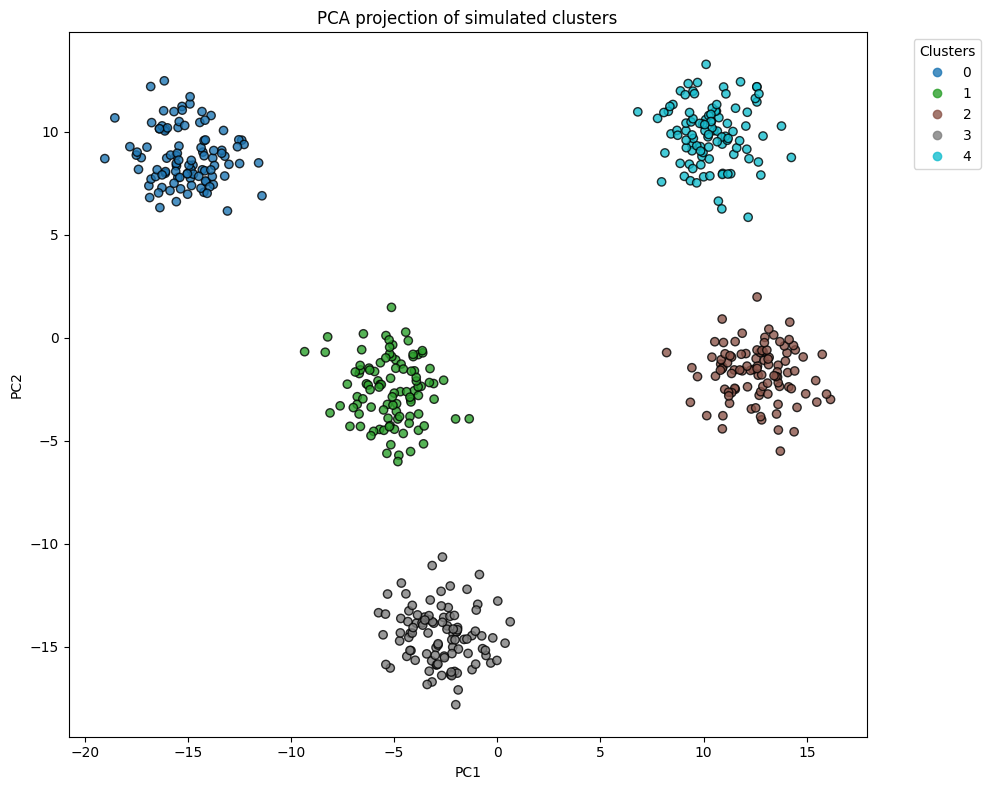

In [447]:
alpha_1_min = 0.04
factors = [alpha_1_min * 50] * 5
_, _ = simulate_clusters(**sim_1_kwargs, k=5, cluster_scale=factors, plotting=True)

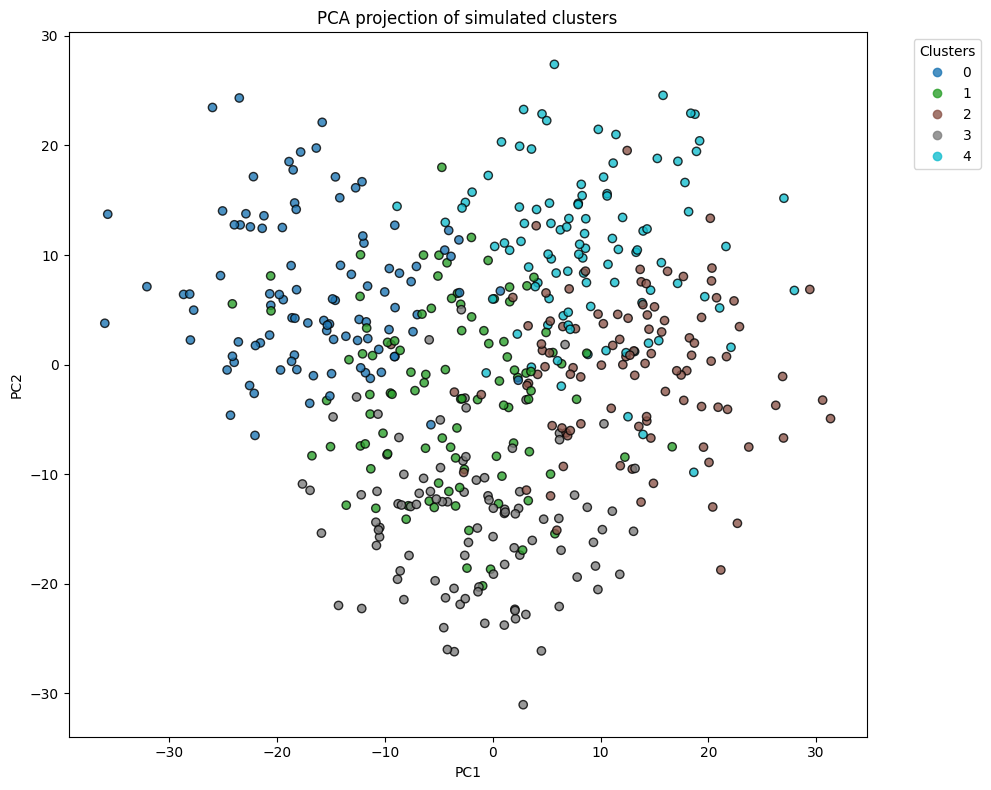

In [448]:
alpha_1_max = 1
factors = [alpha_1_max * 50] * 5
_, _ = simulate_clusters(**sim_1_kwargs, k=5, cluster_scale=factors, plotting=True)

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

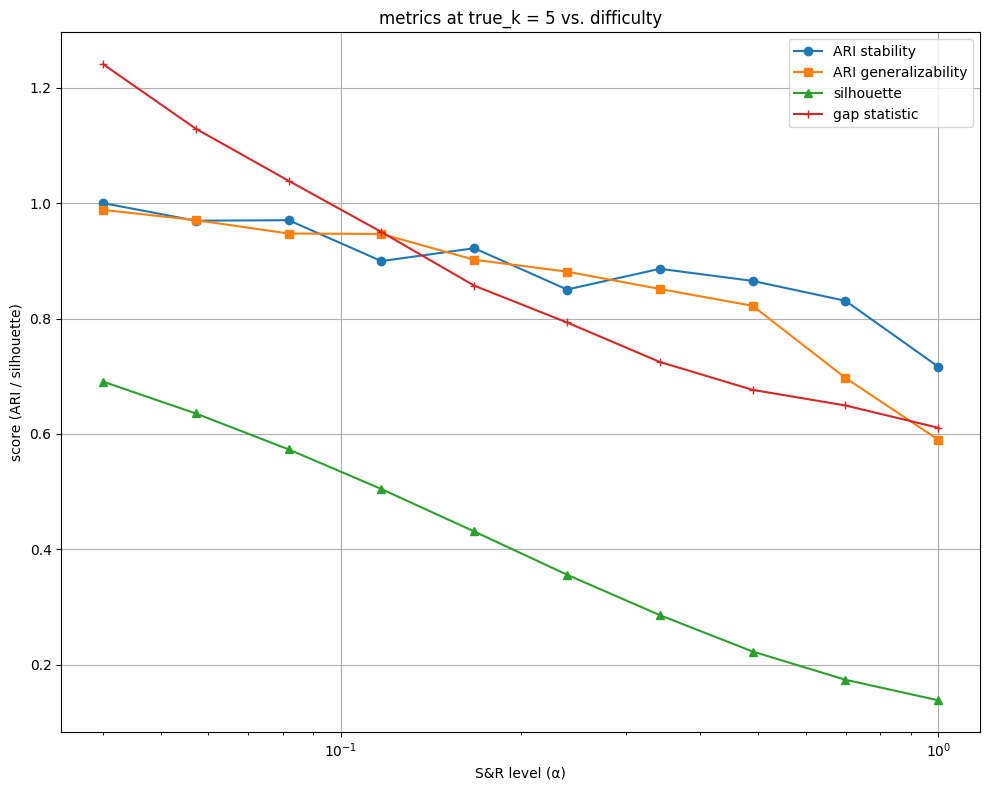

In [449]:
# alphas = np.linspace(alpha_1_min, alpha_1_max, 10)
alphas = np.logspace(np.log10(alpha_1_min), np.log10(alpha_1_max), 10)
factors = [50] * 5
true_k = 5
df_true = benchmark_true_k(true_k=true_k, alphas=alphas, factors=factors, sim_kwargs=sim_1_kwargs)

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    df_true['alpha'],
    df_true['ari_stability'],
    marker='o',
    label='ARI stability'
)
ax.plot(
    df_true['alpha'],
    df_true['ari_generalizability'],
    marker='s',
    label='ARI generalizability'
)
ax.plot(
    df_true['alpha'],
    df_true['silhouette'],
    marker='^',
    label='silhouette'
)
ax.plot(
    df_true['alpha'],
    df_true['gap'],
    marker='+',
    label='gap statistic'
)

ax.set_xscale('log')
ax.set_xlabel('S&R level (α)')
ax.set_ylabel('score (ARI / silhouette)')
ax.set_title(f'metrics at true_k = {true_k} vs. difficulty')
ax.legend(loc='best')
ax.grid(True)

plt.tight_layout()
plt.show()

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

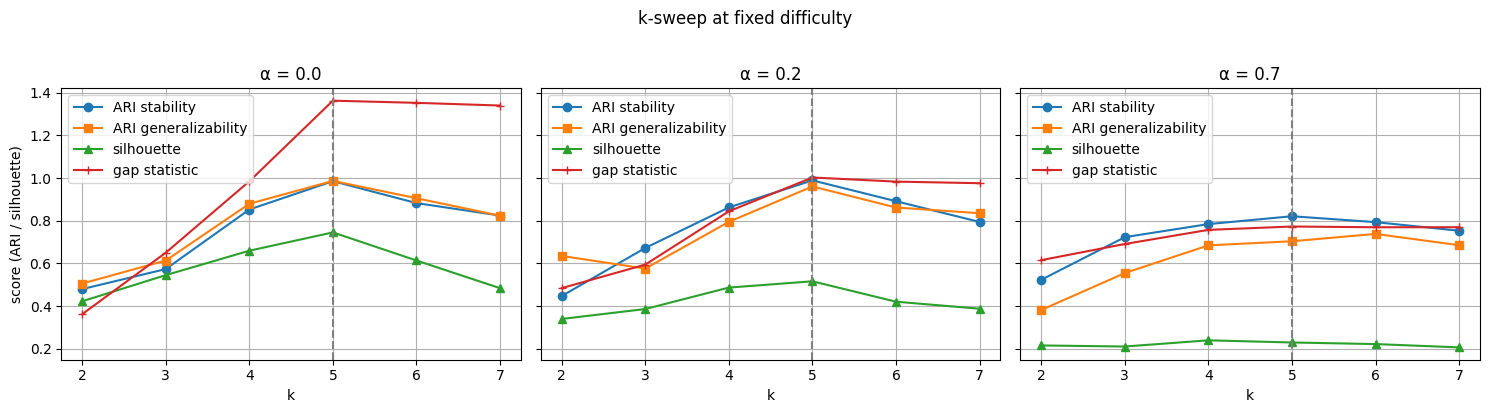

In [490]:
alphas = np.logspace(np.log10(alpha_1_min), np.log10(alpha_1_max), 10)
anchors = [alphas[0], alphas[4], alphas[8]]
df_k = benchmark_k_sweep(anchor_alphas=alphas, factors=factors, true_k=5, K_max=7, sim_kwargs=sim_1_kwargs)

fig, axs = plt.subplots(1, len(anchors), figsize=(15, 4), sharey=True)

for ax, alpha in zip(axs, anchors):
    sub = df_k[np.isclose(df_k['alpha'], alpha, rtol=1e-6)]

    ax.plot(
        sub['n_clusters'],
        sub['ari_stability'],
        marker='o',
        label='ARI stability'
    )
    ax.plot(
        sub['n_clusters'],
        sub['ari_generalizability'],
        marker='s',
        label='ARI generalizability'
    )
    ax.plot(
        sub['n_clusters'],
        sub['silhouette'],
        marker='^',
        label='silhouette'
    )
    ax.plot(
        sub['n_clusters'],
        sub['gap'],
        marker='+',
        label='gap statistic'
    )
    ax.axvline(
        true_k,
        linestyle='--',
        color='gray'
    )

    ax.set_title(f'α = {alpha:.1f}')
    ax.set_xlabel('k')
    if ax is axs[0]:
        ax.set_ylabel('score (ARI / silhouette)')
    ax.legend(loc='best')
    ax.grid(True)

plt.suptitle('k-sweep at fixed difficulty', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
methods = [
    ('ari_stability', 'ARI stability'),
    ('ari_generalizability', 'ARI generalizability'),
    ('silhouette', 'silhouette'),
    ('gap', 'gap statistic'),
]

print("optimal k per method at each difficulty anchor:\n")
for alpha in anchors:
    sub = df_k[np.isclose(df_k['alpha'], alpha, rtol=1e-6)]
    print(f"α = {alpha:.2f}:")
    for col, name in methods:
        # idxmax on the metric column, then grab n_clusters
        best_row = sub.loc[sub[col].idxmax()]
        best_k = int(best_row['n_clusters'])
        best_val = best_row[col]
        print(f"  • {name:<24} → k = {best_k}   (value = {best_val:.3f})")
    print()


optimal k per method at each difficulty anchor:

α = 0.10:
  • ARI stability            → k = 5   (value = 0.937)
  • ARI generalizability     → k = 5   (value = 0.959)
  • silhouette               → k = 5   (value = 0.504)
  • gap statistic            → k = 5   (value = 0.946)

α = 0.50:
  • ARI stability            → k = 5   (value = 0.933)
  • ARI generalizability     → k = 5   (value = 0.828)
  • silhouette               → k = 4   (value = 0.237)
  • gap statistic            → k = 7   (value = 0.673)

α = 0.90:
  • ARI stability            → k = 5   (value = 0.714)
  • ARI generalizability     → k = 5   (value = 0.558)
  • silhouette               → k = 4   (value = 0.146)
  • gap statistic            → k = 4   (value = 0.612)



In [ ]:
# initialize counters
hits = {col: 0 for col, _ in methods}
total = len(alphas)

# for each α, see if the argmax k equals true_k
for alpha in alphas:
    sub = df_k[np.isclose(df_k['alpha'], alpha, rtol=1e-6)]
    for col, _ in methods:
        best_k = int(sub.loc[sub[col].idxmax()]['n_clusters'])
        if best_k == true_k:
            hits[col] += 1

# print percentages
print(f"Out of {total} difficulty levels (alphas), percent of times each method picked k = {true_k}:\n")
for col, name in methods:
    pct = hits[col] / total * 100
    print(f"  • {name:<24} {pct:5.1f}%")


Out of 10 difficulty levels (alphas), percent of times each method picked k = 5:

  • ARI stability            100.0%
  • ARI generalizability     100.0%
  • silhouette                60.0%
  • gap statistic             60.0%


### 3.2 Unbalanced and correlated t-distributed clusters:

In [476]:
sim_2_kwargs = {
    'n_total': 500,
    'p': 20,
    'balanced': False,
    'corr_type': 'ar1',
    'corr_strength': -0.9,
    'distribution': 't',
    'random_state': 7
}

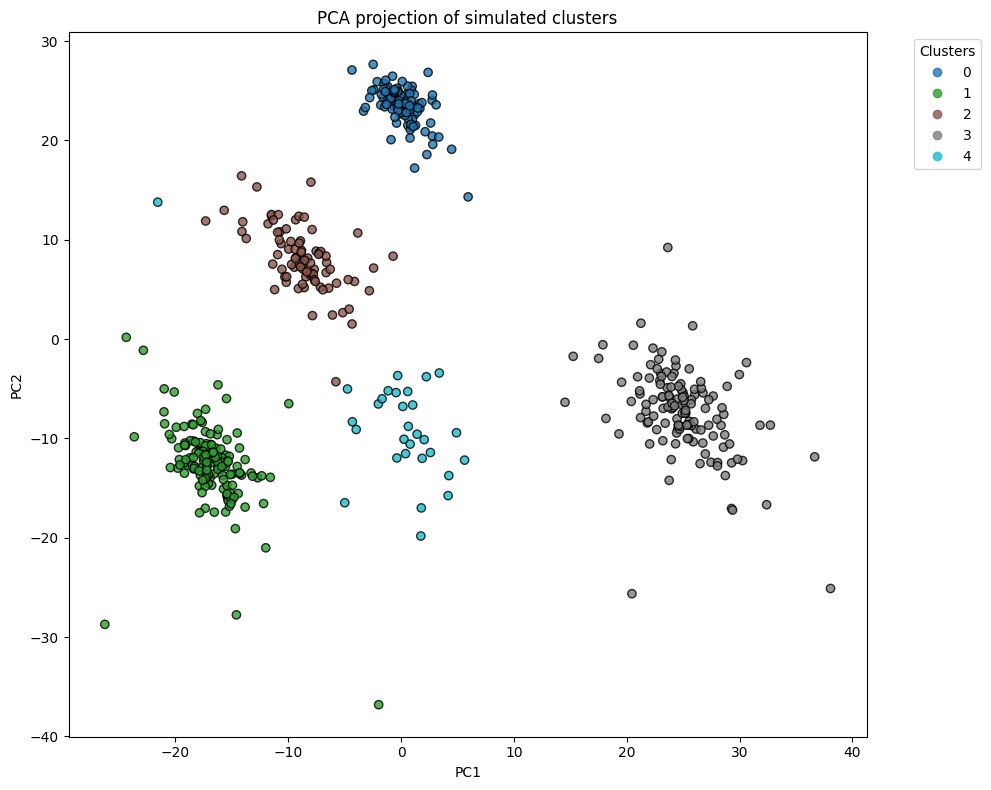

In [401]:
alpha_2_min = 0.1
sizes = [1, 2, 3, 4, 5]
factors = [alpha_2_min*12*size for size in sizes]
_, _ = simulate_clusters(**sim_2_kwargs, k=5, cluster_scale=factors, plotting=True)

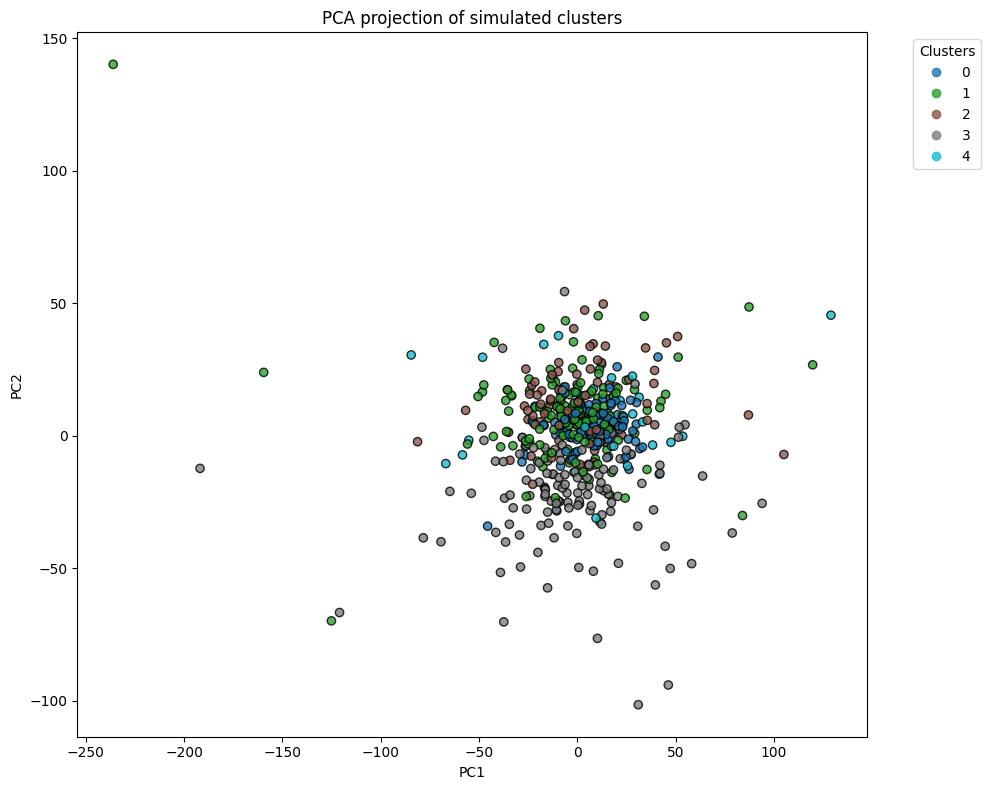

In [402]:
alpha_2_max = 1
sizes = [1, 2, 3, 4, 5]
factors = [alpha_2_max*12*size for size in sizes]
_, _ = simulate_clusters(**sim_2_kwargs, k=5, cluster_scale=factors, plotting=True)

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/1 [00:00<?, ?it/s]

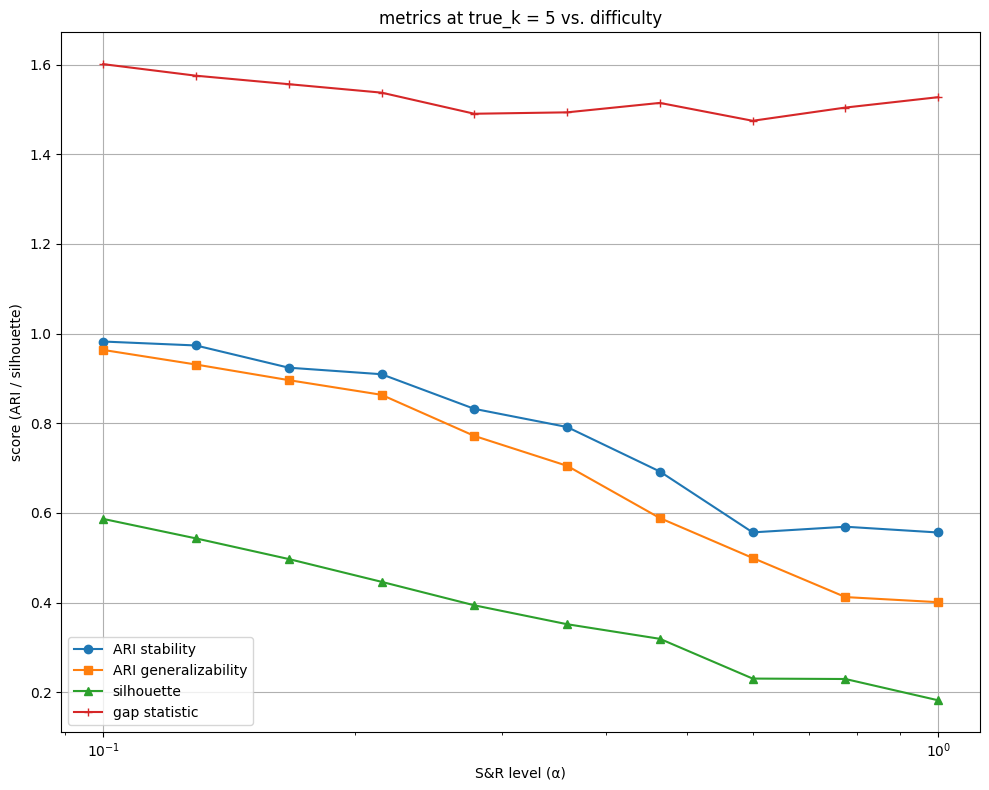

In [477]:
# alphas = np.linspace(alpha_2_min, alpha_2_max, 10)
alphas = np.logspace(np.log10(alpha_2_min), np.log10(alpha_2_max), 10)
sizes = [1, 2, 3, 4, 5]
factors = [12*size for size in sizes]
model_grid = [
    (AgglomerativeClustering, {'n_clusters': [5], 'linkage': ['ward']})
]
true_k = 5
df_true = benchmark_true_k(true_k=true_k, alphas=alphas, factors=factors, sim_kwargs=sim_2_kwargs, model_grid=model_grid)

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    df_true['alpha'],
    df_true['ari_stability'],
    marker='o',
    label='ARI stability'
)
ax.plot(
    df_true['alpha'],
    df_true['ari_generalizability'],
    marker='s',
    label='ARI generalizability'
)
ax.plot(
    df_true['alpha'],
    df_true['silhouette'],
    marker='^',
    label='silhouette'
)
ax.plot(
    df_true['alpha'],
    df_true['gap'],
    marker='+',
    label='gap statistic'
)

ax.set_xscale('log')
ax.set_xlabel('S&R level (α)')
ax.set_ylabel('score (ARI / silhouette)')
ax.set_title(f'metrics at true_k = {true_k} vs. difficulty')
ax.legend(loc='best')
ax.grid(True)

plt.tight_layout()
plt.show()

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

Grid configs:   0%|          | 0/6 [00:00<?, ?it/s]

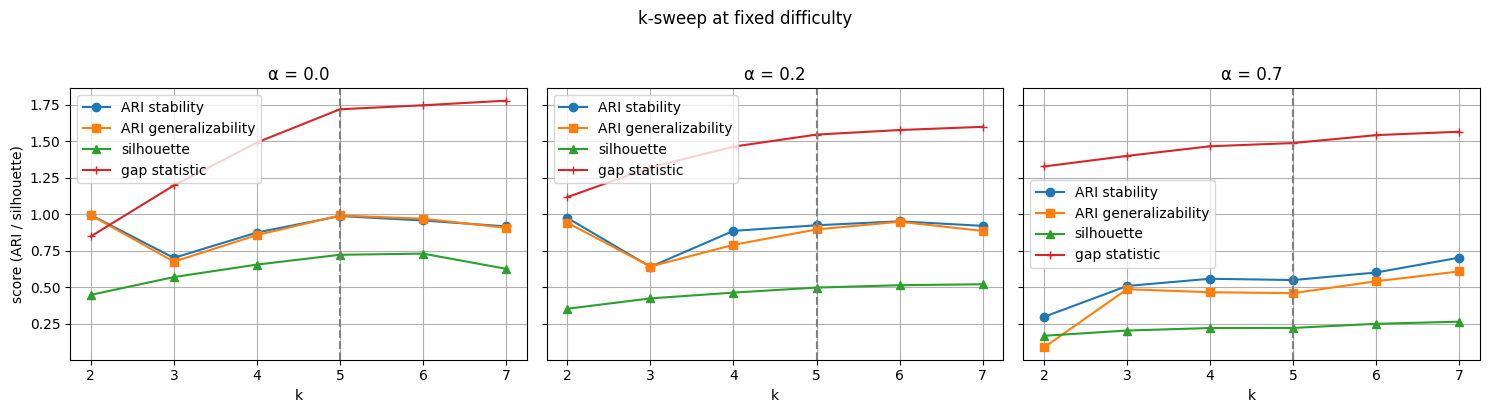

In [491]:
model_grid = [
    (AgglomerativeClustering, {'n_clusters': list(range(2, 7+1)), 'linkage': ['ward']})
]
anchors = [alphas[0], alphas[4], alphas[8]]
df_k = benchmark_k_sweep(anchor_alphas=alphas, factors=factors, true_k=5, K_max=7, sim_kwargs=sim_2_kwargs, model_grid=model_grid)

fig, axs = plt.subplots(1, len(anchors), figsize=(15, 4), sharey=True)

for ax, alpha in zip(axs, anchors):
    sub = df_k[np.isclose(df_k['alpha'], alpha, rtol=1e-6)]

    ax.plot(
        sub['n_clusters'],
        sub['ari_stability'],
        marker='o',
        label='ARI stability'
    )
    ax.plot(
        sub['n_clusters'],
        sub['ari_generalizability'],
        marker='s',
        label='ARI generalizability'
    )
    ax.plot(
        sub['n_clusters'],
        sub['silhouette'],
        marker='^',
        label='silhouette'
    )
    ax.plot(
        sub['n_clusters'],
        sub['gap'],
        marker='+',
        label='gap statistic'
    )
    ax.axvline(
        true_k,
        linestyle='--',
        color='gray'
    )

    ax.set_title(f'α = {alpha:.1f}')
    ax.set_xlabel('k')
    if ax is axs[0]:
        ax.set_ylabel('score (ARI / silhouette)')
    ax.legend(loc='best')
    ax.grid(True)

plt.suptitle('k-sweep at fixed difficulty', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
methods = [
    ('ari_stability', 'ARI stability'),
    ('ari_generalizability', 'ARI generalizability'),
    ('silhouette', 'silhouette'),
    ('gap', 'gap statistic'),
]

print("optimal k per method at each difficulty anchor:\n")
for alpha in anchors:
    sub = df_k[np.isclose(df_k['alpha'], alpha, rtol=1e-6)]
    print(f"α = {alpha:.2f}:")
    for col, name in methods:
        # idxmax on the metric column, then grab n_clusters
        best_row = sub.loc[sub[col].idxmax()]
        best_k = int(best_row['n_clusters'])
        best_val = best_row[col]
        print(f"  • {name:<24} → k = {best_k}   (value = {best_val:.3f})")
    print()

optimal k per method at each difficulty anchor:

α = 0.04:
  • ARI stability            → k = 2   (value = 0.994)
  • ARI generalizability     → k = 2   (value = 0.993)
  • silhouette               → k = 6   (value = 0.730)
  • gap statistic            → k = 7   (value = 1.779)

α = 0.17:
  • ARI stability            → k = 2   (value = 0.974)
  • ARI generalizability     → k = 6   (value = 0.948)
  • silhouette               → k = 7   (value = 0.520)
  • gap statistic            → k = 7   (value = 1.599)

α = 0.70:
  • ARI stability            → k = 7   (value = 0.702)
  • ARI generalizability     → k = 7   (value = 0.608)
  • silhouette               → k = 7   (value = 0.263)
  • gap statistic            → k = 7   (value = 1.566)



In [493]:
# initialize counters
hits = {col: 0 for col, _ in methods}
total = len(alphas)

# for each α, see if the argmax k equals true_k
for alpha in alphas:
    sub = df_k[np.isclose(df_k['alpha'], alpha, rtol=1e-6)]
    for col, _ in methods:
        best_k = int(sub.loc[sub[col].idxmax()]['n_clusters'])
        if best_k == true_k:
            hits[col] += 1

# print percentages
print(f"Out of {total} difficulty levels (alphas), percent of times each method picked k = {true_k}:\n")
for col, name in methods:
    pct = hits[col] / total * 100
    print(f"  • {name:<24} {pct:5.1f}%")


Out of 10 difficulty levels (alphas), percent of times each method picked k = 5:

  • ARI stability             10.0%
  • ARI generalizability      10.0%
  • silhouette                 0.0%
  • gap statistic              0.0%


Exception ignored in: <function ResourceTracker.__del__ at 0x102e65620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1066ed620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
Chi